In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)
pd.set_option("display.max_columns", None)


In [5]:
lists_df = pd.read_csv("./dataset/lists_cleaned.csv")
reviews_df = pd.read_csv("./dataset/reviews_cleaned.csv")

In [6]:
lists_df.head()

,id,title,rating,genre,year
0,tt0369610,Jurassic World,6.9,"Action, Adventure, Sci-Fi",2015
1,tt3774694,Love,6.1,"Drama, Romance",2015
2,tt2361509,The Intern,7.1,"Comedy, Drama",2015
3,tt2381249,Mission: Impossible - Rogue Nation,7.4,"Action, Adventure, Thriller",2015
4,tt3460252,The Hateful Eight,7.8,"Crime, Drama, Mystery",2015


In [7]:
reviews_df.head()

,id,review_title,review_rating,review_text,clean_review
0,tt0369610,"Spielberg Magic, This Is Not. Still, a Visit t...",7.0,You may have heard some critics champion Juras...,you may have heard some critics champion juras...
1,tt0369610,"Not a patch on the original Jurassic Park, and...",7.0,The original Jurassic Park still is a personal...,the original jurassic park still is a personal...
2,tt0369610,Its a Jurassic World after all.,7.0,The 4th film in the Jurassic Park series and t...,the th film in the jurassic park series and th...
3,tt0369610,Worthy Sequel To One Of The Greatest Films Eve...,0.0,Let's start this by stating how much of a die ...,lets start this by stating how much of a die h...
4,tt0369610,Manages to somewhat return the Jurassic Park s...,6.0,Modernized and polished entry to the Jurassic ...,modernized and polished entry to the jurassic ...


In [8]:
lists_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      250 non-null    object 
 1   title   250 non-null    object 
 2   rating  250 non-null    float64
 3   genre   250 non-null    object 
 4   year    250 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 9.9+ KB


In [9]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6216 entries, 0 to 6215
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6216 non-null   object 
 1   review_title   6216 non-null   object 
 2   review_rating  6216 non-null   float64
 3   review_text    6216 non-null   object 
 4   clean_review   6216 non-null   object 
dtypes: float64(1), object(4)
memory usage: 242.9+ KB


In [10]:
lists_df.isnull().sum()

id        0
title     0
rating    0
genre     0
year      0
dtype: int64

In [11]:
reviews_df.isnull().sum()

id               0
review_title     0
review_rating    0
review_text      0
clean_review     0
dtype: int64

In [12]:
#VADER
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

reviews_df["sentiment_score"] = reviews_df["clean_review"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

reviews_df["sentiment_label"] = reviews_df["sentiment_score"].apply(label_sentiment)
reviews_df["sentiment_label"].value_counts()

sentiment_label
positive    4912
negative    1242
neutral       62
Name: count, dtype: int64

In [13]:
from transformers import pipeline

bert_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

def bert_predict(text):
    result = bert_classifier(text[:512])[0]
    return pd.Series([result["label"].lower(), result["score"]])

reviews_df[["bert_label", "bert_confidence"]] = reviews_df["clean_review"].apply(bert_predict)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [14]:
reviews_df[["clean_review", "bert_label", "bert_confidence"]].head()

,clean_review,bert_label,bert_confidence
0,you may have heard some critics champion juras...,negative,0.991350
1,the original jurassic park still is a personal...,positive,0.943678
2,the th film in the jurassic park series and th...,negative,0.999510
3,lets start this by stating how much of a die h...,negative,0.991898
4,modernized and polished entry to the jurassic ...,positive,0.967235


In [15]:
merged_df = reviews_df.merge(
    lists_df[["id", "title", "year", "genre", "rating"]],
    on="id",
    how="left"
)
merged_df.head()

,id,review_title,review_rating,review_text,clean_review,sentiment_score,sentiment_label,bert_label,bert_confidence,title,year,genre,rating
0,tt0369610,"Spielberg Magic, This Is Not. Still, a Visit t...",7.0,You may have heard some critics champion Juras...,you may have heard some critics champion juras...,0.9988,positive,negative,0.991350,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9
1,tt0369610,"Not a patch on the original Jurassic Park, and...",7.0,The original Jurassic Park still is a personal...,the original jurassic park still is a personal...,0.9986,positive,positive,0.943678,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9
2,tt0369610,Its a Jurassic World after all.,7.0,The 4th film in the Jurassic Park series and t...,the th film in the jurassic park series and th...,-0.6089,negative,negative,0.999510,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9
3,tt0369610,Worthy Sequel To One Of The Greatest Films Eve...,0.0,Let's start this by stating how much of a die ...,lets start this by stating how much of a die h...,0.9947,positive,negative,0.991898,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9
4,tt0369610,Manages to somewhat return the Jurassic Park s...,6.0,Modernized and polished entry to the Jurassic ...,modernized and polished entry to the jurassic ...,0.8078,positive,positive,0.967235,Jurassic World,2015,"Action, Adventure, Sci-Fi",6.9


In [16]:
merged_df.to_csv("merged_df.csv", index=False)

In [17]:
import nltk
nltk.download("punkt", quiet=False)
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if w.lower() not in stop_words]
    tokens = [lemmatizer.lemmatize(w.lower()) for w in tokens]
    return tokens

merged_df["tokens_processed"] = merged_df["clean_review"].apply(preprocess)

[nltk_data] Downloading package punkt to /Users/sharon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sharon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sharon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/sharon/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [18]:
merged_df.columns

Index(['id', 'review_title', 'review_rating', 'review_text', 'clean_review',
       'sentiment_score', 'sentiment_label', 'bert_label', 'bert_confidence',
       'title', 'year', 'genre', 'rating', 'tokens_processed'],
      dtype='object')

In [19]:
def tokenize(text):
    return nltk.word_tokenize(text)

merged_df["tokens"] = merged_df["clean_review"].apply(tokenize)

In [20]:
merged_df[["clean_review", "tokens"]].head()

,clean_review,tokens
0,you may have heard some critics champion juras...,"[you, may, have, heard, some, critics, champio..."
1,the original jurassic park still is a personal...,"[the, original, jurassic, park, still, is, a, ..."
2,the th film in the jurassic park series and th...,"[the, th, film, in, the, jurassic, park, serie..."
3,lets start this by stating how much of a die h...,"[lets, start, this, by, stating, how, much, of..."
4,modernized and polished entry to the jurassic ...,"[modernized, and, polished, entry, to, the, ju..."


In [21]:
merged_df["tokens"] = merged_df["clean_review"].apply(nltk.word_tokenize)

In [22]:
merged_df.to_csv("merged_df_with_tokens.csv", index=False)

In [23]:
merged_df = pd.read_csv("merged_df_with_tokens.csv")

In [24]:
#VADER VS BERT

#Yearly Vader
yearly_vader = merged_df.groupby("year")["sentiment_score"].mean().reset_index()

In [25]:
#Bert
merged_df["bert_binary"] = merged_df["bert_label"].map({"positive": 1, "negative": 0})
yearly_bert = merged_df.groupby("year")["bert_binary"].mean().reset_index()
yearly_bert.rename(columns={"bert_binary": "bert_positive_ratio"}, inplace=True)

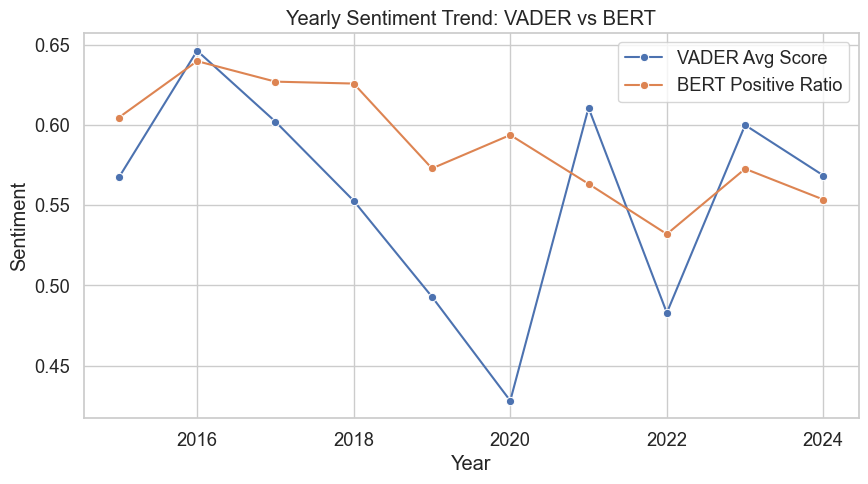

In [26]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_vader, x="year", y="sentiment_score", marker="o", label="VADER Avg Score")
sns.lineplot(data=yearly_bert, x="year", y="bert_positive_ratio", marker="o", label="BERT Positive Ratio")
plt.title("Yearly Sentiment Trend: VADER vs BERT")
plt.xlabel("Year")
plt.ylabel("Sentiment")
plt.legend()
plt.show()

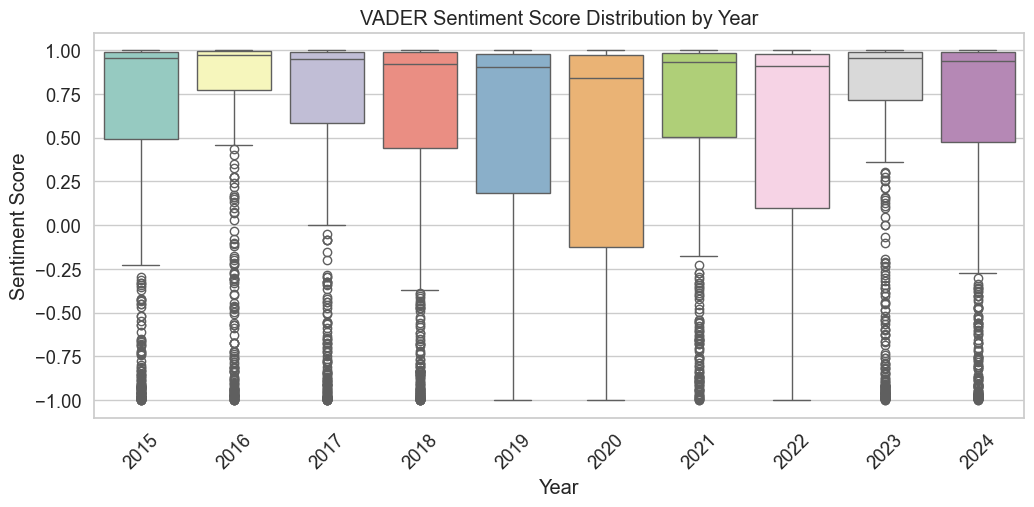

In [27]:
#vader
plt.figure(figsize=(12,5))
sns.boxplot(data=merged_df, 
            x="year", 
            y="sentiment_score",
            hue="year",
            palette="Set3",
            legend=False
)
plt.title("VADER Sentiment Score Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()

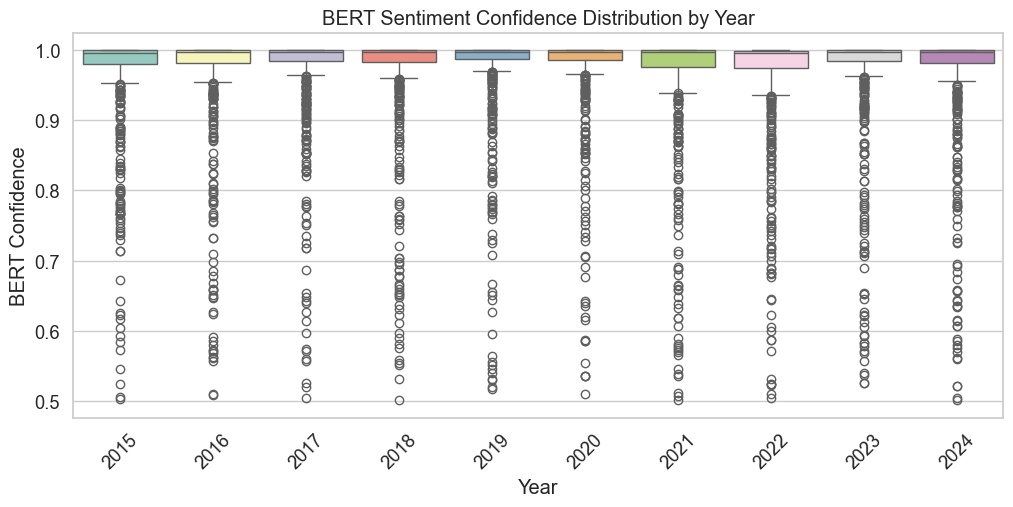

In [28]:
#bert
plt.figure(figsize=(12,5))
sns.boxplot(data=merged_df, 
            x="year", 
            y="bert_confidence",
            hue="year",
            palette="Set3",
            legend=False
)
plt.title("BERT Sentiment Confidence Distribution by Year")
plt.xlabel("Year")
plt.ylabel("BERT Confidence")
plt.xticks(rotation=45)
plt.show()

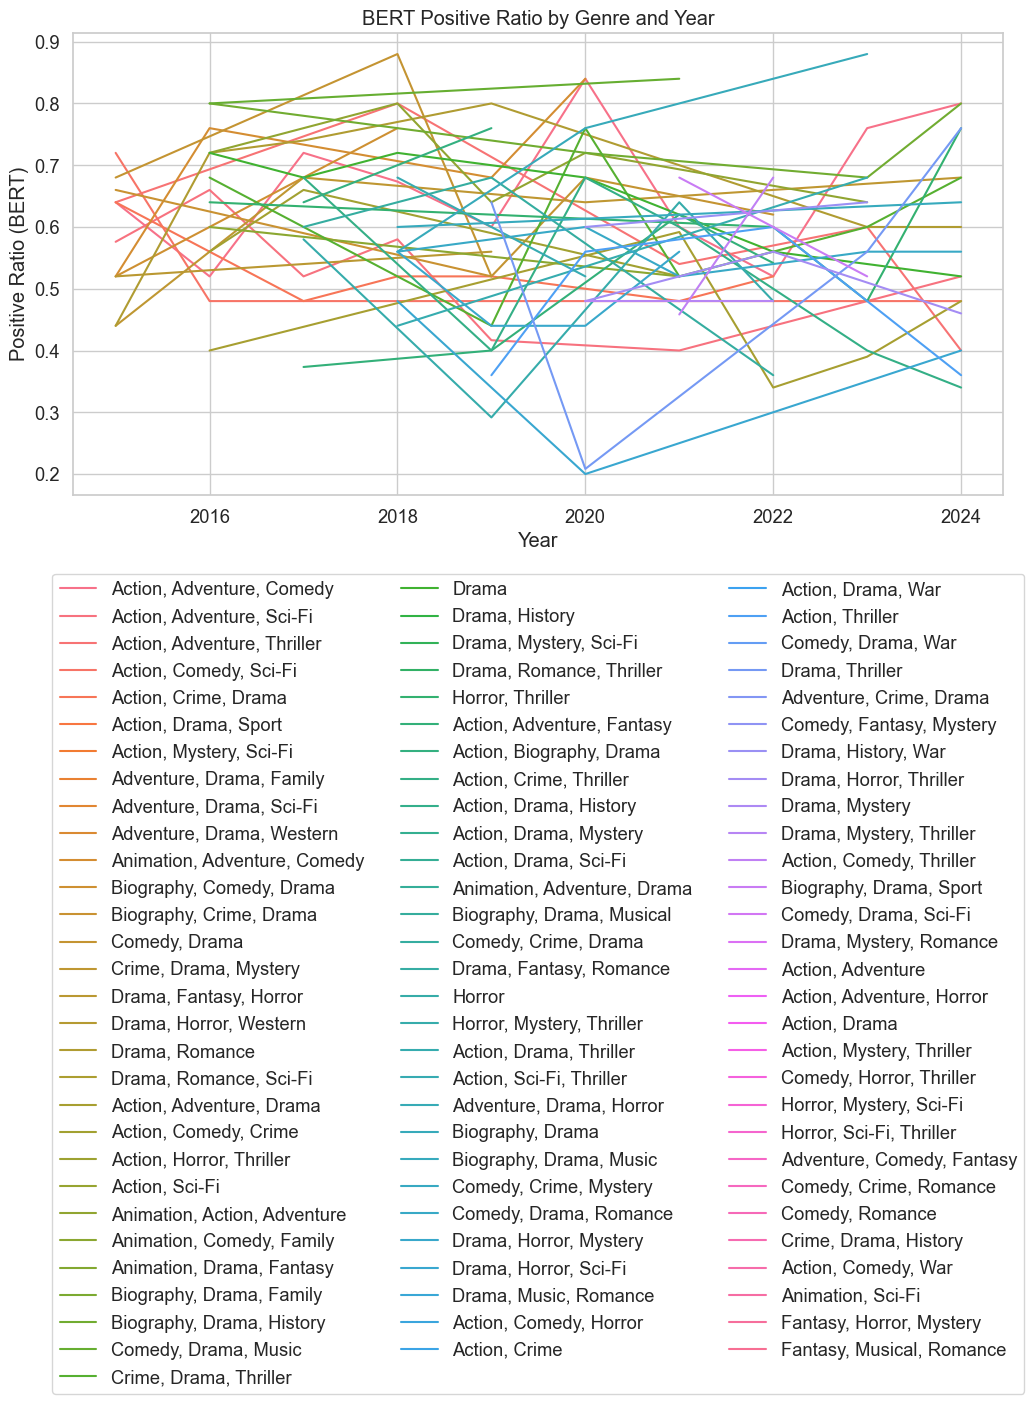

In [29]:
genre_bert = merged_df.groupby(["year", "genre"])["bert_binary"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=genre_bert, x="year", y="bert_binary", hue="genre")
plt.title("BERT Positive Ratio by Genre and Year")
plt.xlabel("Year")
plt.ylabel("Positive Ratio (BERT)")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.show()

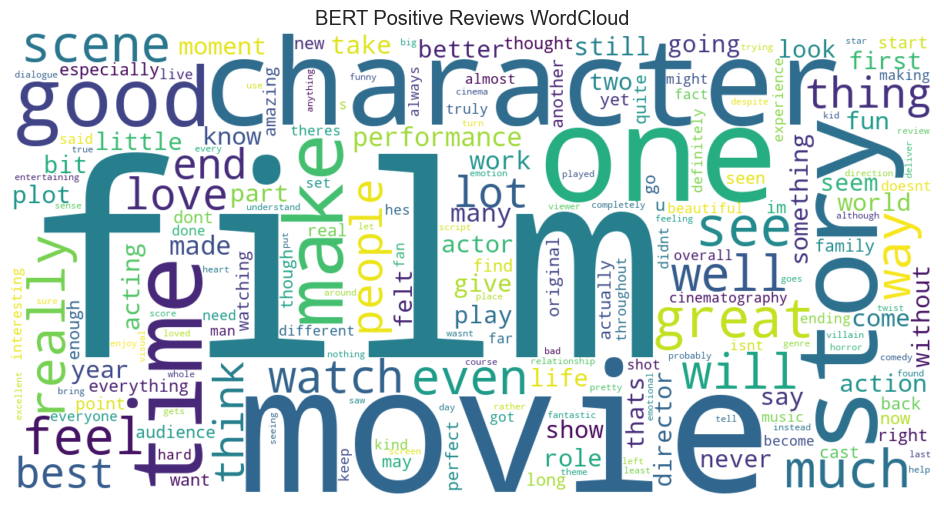

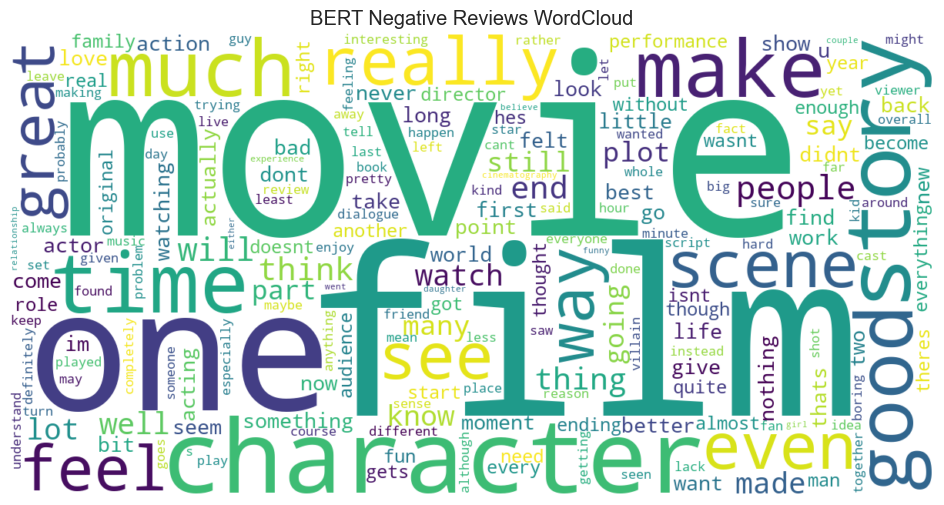

In [30]:
from wordcloud import WordCloud

pos_text = " ".join(merged_df[merged_df["bert_label"] == "positive"]["clean_review"].astype(str))
neg_text = " ".join(merged_df[merged_df["bert_label"] == "negative"]["clean_review"].astype(str))

# Positive
wc_pos = WordCloud(width=1200, height=600, background_color="white").generate(pos_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("BERT Positive Reviews WordCloud")
plt.show()

# Negative
wc_neg = WordCloud(width=1200, height=600, background_color="white").generate(neg_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("BERT Negative Reviews WordCloud")
plt.show()

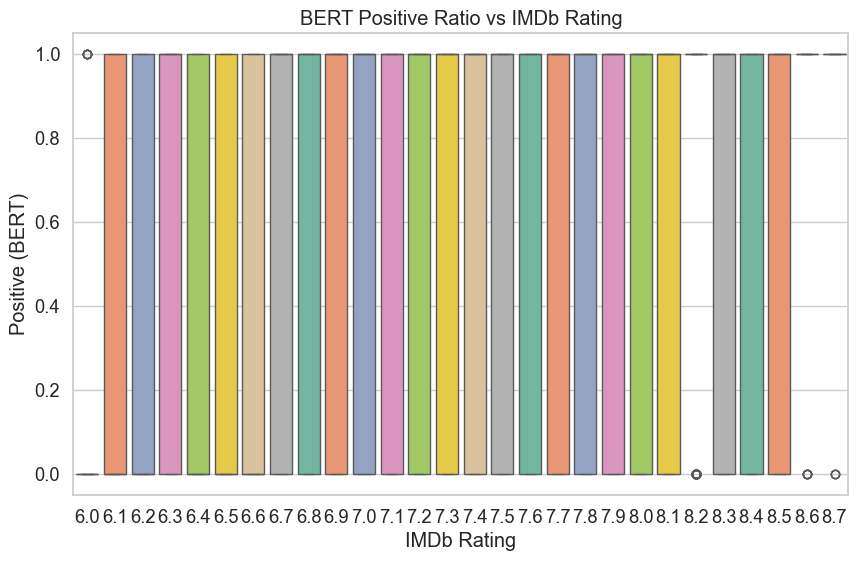

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=merged_df,
    x="rating",
    y="bert_binary",
    hue="rating",
    palette="Set2",
    legend=False
)
plt.title("BERT Positive Ratio vs IMDb Rating")
plt.xlabel("IMDb Rating")
plt.ylabel("Positive (BERT)")
plt.show()

In [32]:
## NLP - TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf = TfidfVectorizer(max_features=3000, stop_words="english")

def top_tfidf_words(texts, top_n=20):
    X = tfidf.fit_transform(texts)
    scores = zip(tfidf.get_feature_names_out(), X.sum(axis=0).tolist()[0])
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return sorted_scores[:top_n]

year_list = sorted(merged_df["year"].unique())

for y in year_list:
    print(f"\n=== Year {y} ===")
    texts = merged_df[merged_df["year"] == y]["clean_review"]
    print(top_tfidf_words(texts))


=== Year 2015 ===
[('film', 40.21772357824215), ('movie', 38.07505691428069), ('just', 21.00869663418932), ('like', 18.63481834452866), ('story', 18.54616561293084), ('good', 17.69207175485978), ('action', 17.504178538379634), ('great', 17.400864523592865), ('really', 17.240143007523578), ('characters', 14.500886033789872), ('films', 14.190539914620208), ('time', 13.649332867583192), ('character', 13.065951638648627), ('movies', 12.830499911986509), ('people', 12.478311760419455), ('love', 11.663554370562515), ('best', 11.62669041262655), ('did', 11.46830608794035), ('watch', 11.267791813757945), ('plot', 11.126851006596652)]

=== Year 2016 ===
[('movie', 42.43329377615662), ('film', 40.34239123040984), ('story', 20.13912641114685), ('just', 19.41713491724938), ('like', 19.3944833742597), ('good', 17.444750797858713), ('great', 16.50567421840353), ('really', 16.352650425926015), ('characters', 15.930650009204488), ('time', 14.724145703892573), ('character', 12.84534686934933), ('movie

In [33]:
genres = merged_df["genre"].unique()

for g in genres:
    print(f"\n=== Genre: {g} ===")
    texts = merged_df[merged_df["genre"] == g]["clean_review"]
    print(top_tfidf_words(texts))


=== Genre: Action, Adventure, Sci-Fi ===
[('movie', 30.72078711162903), ('film', 26.50457001666721), ('like', 14.410187200582628), ('just', 14.098836403076598), ('great', 13.345293934887724), ('star', 13.05704094677299), ('good', 12.804542086677444), ('action', 12.632509723522675), ('really', 12.536212683191739), ('story', 12.447251896440587), ('wars', 11.502571099958827), ('characters', 11.214298096813192), ('marvel', 10.936345050264151), ('movies', 10.246252977650304), ('time', 10.216465920986863), ('character', 10.05431284717825), ('best', 9.525192268362911), ('films', 8.742105127452083), ('dont', 8.527577109126861), ('world', 8.487252998350575)]

=== Genre: Drama, Romance ===
[('film', 13.104398226756832), ('movie', 11.931160646387355), ('love', 9.095806564010426), ('story', 7.056139656372346), ('like', 6.932088698989099), ('just', 6.465262842390187), ('time', 6.14350907868169), ('really', 5.57543609116332), ('characters', 5.340511755706516), ('sex', 5.333964104971851), ('beautifu

In [34]:
pos_texts = merged_df[merged_df["bert_label"] == "positive"]["clean_review"]
neg_texts = merged_df[merged_df["bert_label"] == "negative"]["clean_review"]

print("\n=== Positive TF-IDF ===")
print(top_tfidf_words(pos_texts))

print("\n=== Negative TF-IDF ===")
print(top_tfidf_words(neg_texts))


=== Positive TF-IDF ===
[('movie', 242.10312968762278), ('film', 215.65074508486148), ('like', 113.54217110790619), ('good', 111.9872139099006), ('story', 111.30667858092178), ('just', 107.47078605502013), ('great', 106.8909369198611), ('really', 98.73104080489051), ('time', 83.18632817747417), ('action', 82.63519117908302), ('best', 80.31692225911745), ('watch', 80.20570320200305), ('characters', 77.31063070130423), ('movies', 72.60511889337748), ('films', 67.79692060475219), ('character', 67.09275446960311), ('dont', 66.36049142430072), ('way', 64.70705825669918), ('love', 64.2290284426939), ('people', 60.40602103526098)]

=== Negative TF-IDF ===
[('movie', 168.44322703710463), ('film', 139.5252539329702), ('just', 96.68722198063936), ('like', 94.21690808111545), ('story', 75.68030836689204), ('good', 72.7684937569482), ('really', 70.72376636217876), ('characters', 58.56512192100569), ('time', 58.29276457206339), ('great', 55.881794454219104), ('character', 55.81006766705829), ('don

In [35]:
##N-grams
from sklearn.feature_extraction.text import CountVectorizer

def get_ngrams(texts, n=2, top_n=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english")
    X = vec.fit_transform(texts)
    counts = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    freq = list(zip(vocab, counts))
    return sorted(freq, key=lambda x: x[1], reverse=True)[:top_n]

In [36]:
print("=== Top Bigrams ===")
print(get_ngrams(merged_df["clean_review"], n=2))

print("\n=== Top Trigrams ===")
print(get_ngrams(merged_df["clean_review"], n=3))

=== Top Bigrams ===
[('feel like', np.int64(387)), ('star wars', np.int64(364)), ('felt like', np.int64(360)), ('feels like', np.int64(355)), ('ive seen', np.int64(349)), ('dont know', np.int64(260)), ('action scenes', np.int64(234)), ('john wick', np.int64(217)), ('movie just', np.int64(215)), ('action sequences', np.int64(205)), ('character development', np.int64(200)), ('good movie', np.int64(199)), ('really good', np.int64(191)), ('dont think', np.int64(189)), ('movie really', np.int64(181)), ('main character', np.int64(179)), ('special effects', np.int64(163)), ('action movie', np.int64(155)), ('im sure', np.int64(152)), ('like movie', np.int64(143))]

=== Top Trigrams ===
[('did great job', np.int64(72)), ('la la land', np.int64(47)), ('based true story', np.int64(43)), ('hell high water', np.int64(43)), ('does good job', np.int64(42)), ('did good job', np.int64(37)), ('does great job', np.int64(37)), ('john wick chapter', np.int64(33)), ('movies ive seen', np.int64(33)), ('films

In [37]:
print("\n=== Positive Bigrams ===")
print(get_ngrams(pos_texts, n=2))

print("\n=== Negative Bigrams ===")
print(get_ngrams(neg_texts, n=2))


=== Positive Bigrams ===
[('feel like', np.int64(228)), ('ive seen', np.int64(223)), ('star wars', np.int64(212)), ('feels like', np.int64(193)), ('action sequences', np.int64(141)), ('action scenes', np.int64(139)), ('felt like', np.int64(137)), ('dont know', np.int64(128)), ('good movie', np.int64(123)), ('really good', np.int64(119)), ('movie really', np.int64(116)), ('john wick', np.int64(112)), ('dont think', np.int64(105)), ('long time', np.int64(99)), ('comic book', np.int64(97)), ('film does', np.int64(94)), ('special effects', np.int64(94)), ('character development', np.int64(93)), ('big screen', np.int64(88)), ('action movie', np.int64(87))]

=== Negative Bigrams ===
[('felt like', np.int64(223)), ('feels like', np.int64(162)), ('feel like', np.int64(159)), ('star wars', np.int64(152)), ('dont know', np.int64(132)), ('movie just', np.int64(132)), ('ive seen', np.int64(126)), ('character development', np.int64(107)), ('john wick', np.int64(105)), ('main character', np.int64(1